# Wrist Temperature Cluster Prediction — Machine Learning Models

This notebook trains and evaluates Random Forest and Neural Network 
models to predict nightly wrist skin temperature cluster membership 
from sleep physiological features collected by the Fitbit Sense wearable.

## Objective
Predict whether a participant's night belongs to the high or low 
skin temperature cluster based on normalized sleep features including 
HRV, respiratory rate, sleep stages, and oxygen saturation.

## Models
- **Random Forest** — ensemble method trained on normalized features
- **Neural Network (MLP)** — two hidden layers (32, 16 units), ReLU 
  activation, Adam optimizer, trained on standardized features

## Evaluation
- Held-out test set performance: accuracy, precision, recall, F1
- ROC AUC comparison between both models
- Confusion matrices for visual error analysis

## Interpretability
- SHAP (SHapley Additive exPlanations) applied to the Random Forest
- Bar plot: mean absolute feature importance across all samples
- Beeswarm plot: direction and magnitude of each feature's impact

## Key Finding
Both models achieved strong predictive performance (AUC > 0.80), 
demonstrating that nocturnal physiological signals captured by 
wearable devices reliably distinguish thermoregulation profiles. 
SHAP analysis identified restlessness, HRV (RMSSD), and REM sleep 
duration as the most influential predictors.

C:\Users\ASUS\anaconda3\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total samples:  2726
Features:       17
Class balance:
aligned_cluster_label
1    1363
0    1363

Train size: 2264 | Test size: 462

RANDOM FOREST
                   precision    recall  f1-score   support

 Low temp cluster       0.60      0.90      0.72       103
High temp cluster       0.97      0.83      0.89       359

         accuracy                           0.84       462
        macro avg       0.78      0.87      0.81       462
     weighted avg       0.89      0.84      0.85       462

ROC AUC: 0.927

NEURAL NETWORK
                   precision    recall  f1-score   support

 Low temp cluster       0.35      0.61      0.44       103
High temp cluster       0.86      0.67      0.75       359

         accuracy                           0.66       462
        macro avg       0.60      0.64      0.60       462
     weighted avg       0.74      0.66      0.68       462

ROC AUC: 0.807


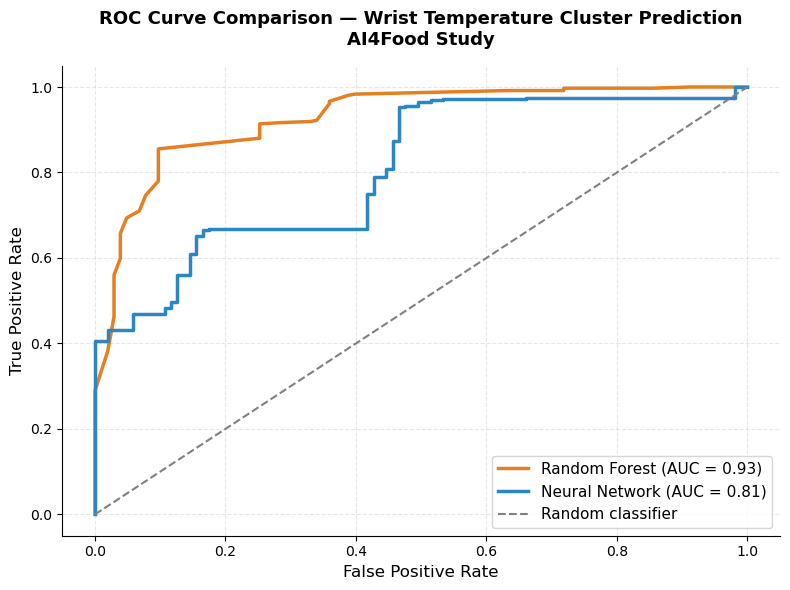

Figure saved: figures/temperature_model_roc.png


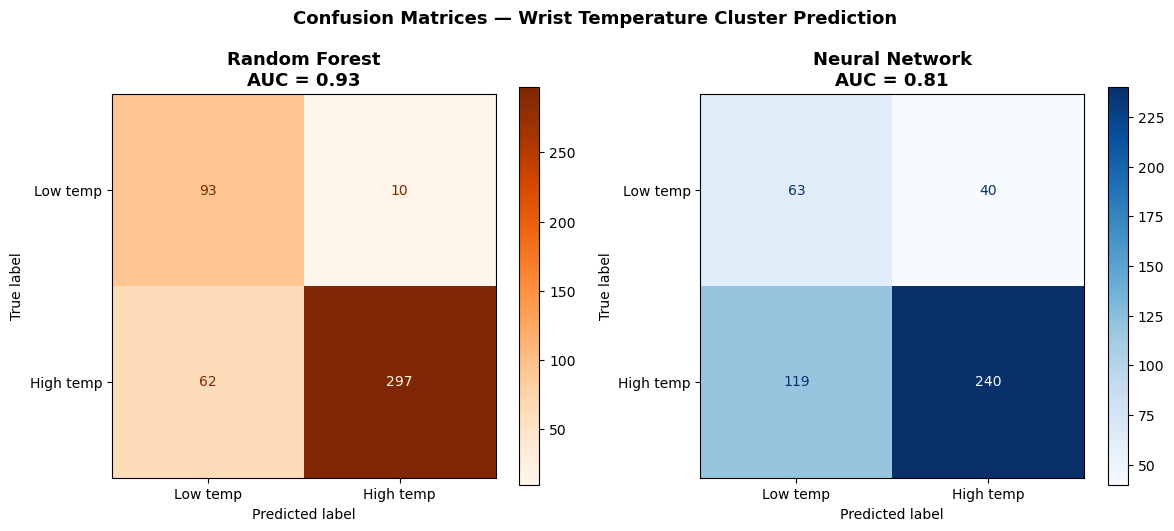

Figure saved: figures/temperature_model_confusion.png

Computing SHAP values...
SHAP values shape: (2726, 17)


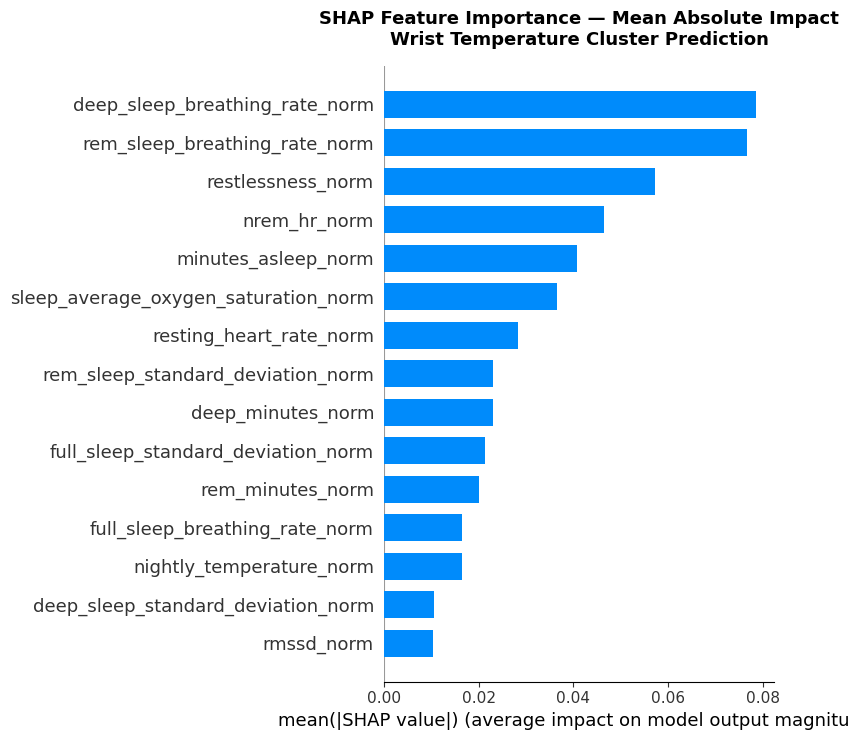

Figure saved: figures/temperature_shap_bar.png


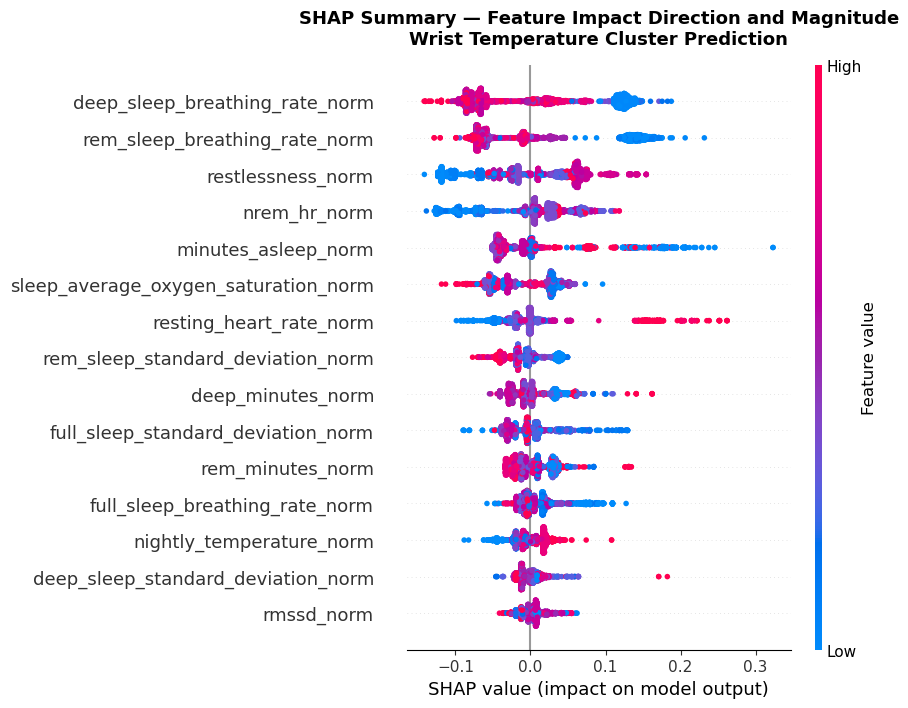

Figure saved: figures/temperature_shap_beeswarm.png


In [1]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
import os

os.makedirs("figures", exist_ok=True)

# CONFIGURATION

DATA_PATH   = "data/balanced_wrist_temp_training_data.xlsx"
TARGET_COL  = "aligned_cluster_label"
ID_COL      = "participant_id"
COLOR_RF    = "#E67E22"
COLOR_NN    = "#2E86C1"

# LOAD DATA

df = pd.read_excel(DATA_PATH)

FEATURE_COLS = [col for col in df.columns if col.endswith('_norm')]

print(f"Total samples:  {len(df)}")
print(f"Features:       {len(FEATURE_COLS)}")
print(f"Class balance:\n{df[TARGET_COL].value_counts().to_string()}")

# TRAIN / TEST SPLIT

train_df = df[df['set'] == 'train']
test_df  = df[df['set'] == 'test']

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COL]
X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET_COL]

print(f"\nTrain size: {len(train_df)} | Test size: {len(test_df)}")

# STANDARDIZE (for Neural Network)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# TRAIN MODELS

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf  = (y_proba_rf >= 0.5).astype(int)

# Neural Network
nn = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)
nn.fit(X_train_scaled, y_train)
y_proba_nn = nn.predict_proba(X_test_scaled)[:, 1]
y_pred_nn  = (y_proba_nn >= 0.5).astype(int)

# EVALUATION SUMMARY

auc_rf = roc_auc_score(y_test, y_proba_rf)
auc_nn = roc_auc_score(y_test, y_proba_nn)

print("\n" + "="*50)
print("RANDOM FOREST")
print("="*50)
print(classification_report(y_test, y_pred_rf,
      target_names=["Low temp cluster", "High temp cluster"]))
print(f"ROC AUC: {auc_rf:.3f}")

print("\n" + "="*50)
print("NEURAL NETWORK")
print("="*50)
print(classification_report(y_test, y_pred_nn,
      target_names=["Low temp cluster", "High temp cluster"]))
print(f"ROC AUC: {auc_nn:.3f}")

# FIGURE 1 : ROC CURVE COMPARISON

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_proba_nn)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr_rf, tpr_rf, color=COLOR_RF, lw=2.5,
        label=f"Random Forest (AUC = {auc_rf:.2f})")
ax.plot(fpr_nn, tpr_nn, color=COLOR_NN, lw=2.5,
        label=f"Neural Network (AUC = {auc_nn:.2f})")
ax.plot([0, 1], [0, 1], color='gray', lw=1.5,
        linestyle='--', label='Random classifier')

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title(
    "ROC Curve Comparison — Wrist Temperature Cluster Prediction\n"
    "AI4Food Study",
    fontsize=13, fontweight='bold', pad=15
)
ax.legend(loc="lower right", fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("figures/temperature_model_roc.png", dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: figures/temperature_model_roc.png")

# FIGURE 2 : CONFUSION MATRICES 

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=["Low temp", "High temp"],
    cmap="Oranges",
    ax=axes[0]
)
axes[0].set_title(
    f"Random Forest\nAUC = {auc_rf:.2f}",
    fontsize=13, fontweight='bold'
)
axes[0].grid(False)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_nn,
    display_labels=["Low temp", "High temp"],
    cmap="Blues",
    ax=axes[1]
)
axes[1].set_title(
    f"Neural Network\nAUC = {auc_nn:.2f}",
    fontsize=13, fontweight='bold'
)
axes[1].grid(False)

plt.suptitle(
    "Confusion Matrices — Wrist Temperature Cluster Prediction",
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig("figures/temperature_model_confusion.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: figures/temperature_model_confusion.png")

# SHAP ANALYSIS

X_all = df[FEATURE_COLS]
y_all = df[TARGET_COL]

rf_full = RandomForestClassifier(n_estimators=100, random_state=42)
rf_full.fit(X_all, y_all)

print("\nComputing SHAP values...")
explainer   = shap.TreeExplainer(rf_full)
shap_values = explainer.shap_values(X_all)

if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_class1 = shap_values[:, :, 1]
elif isinstance(shap_values, list):
    shap_class1 = shap_values[1]
else:
    shap_class1 = shap_values

print(f"SHAP values shape: {shap_class1.shape}")

# FIGURE 3 : SHAP Bar Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_class1, X_all,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title(
    "SHAP Feature Importance — Mean Absolute Impact\n"
    "Wrist Temperature Cluster Prediction",
    fontsize=13, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig("figures/temperature_shap_bar.png", dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: figures/temperature_shap_bar.png")


# FIGURE 4 : SHAP Beeswarm Plot
plt.figure(figsize=(16, 10))
shap.summary_plot(
    shap_class1, X_all,
    max_display=15,
    show=False
)
plt.title(
    "SHAP Summary — Feature Impact Direction and Magnitude\n"
    "Wrist Temperature Cluster Prediction",
    fontsize=13, fontweight='bold', pad=15
)
plt.subplots_adjust(left=0.35, right=0.95, top=0.88, bottom=0.1)
plt.savefig("figures/temperature_shap_beeswarm.png", dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: figures/temperature_shap_beeswarm.png")